# 03: Integer Ops

`int8 in -> ternary GEMM (int32) -> PLAC activation (int32 shifts) -> rescale to int8 -> next layer`

No float multiply in forward pass!

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("../")))

import matplotlib.pyplot as plt
import numpy as np
import torch

## Ternary GEMM: no-multiply

Matmul: $y_j = \sum_i w_{ji} \cdot x_i$ (multiply-accumulate)

Ternary weights $w \in \{-1, 0, +1\}$:

$$y_j = \sum_{i: w=+1} x_i - \sum_{i: w=-1} x_i$$

Additions and subtractions only, the positions are known at compile time (as bitmasks).

In [2]:
x = np.array([10, -3, 7, 0, 5, -2, 8, 1], dtype=np.int8)
w = np.array([1, -1, 0, 1, -1, 0, 1, 1], dtype=np.int8)

# standard: 8 multiplies + 7 adds
y_std = np.sum(x * w)

# ternary: 0 multiplies, just conditional adds
y_add = np.sum(x[w == 1]) - np.sum(x[w == -1])

print(f"standard mul-acc: {y_std}")
print(f"ternary add/sub: {y_add}")
print(f"match: {y_std == y_add}")

standard mul-acc: 17
ternary add/sub: 17
match: True


## TL1 lookup table

Group 2 weights at a time. 3^2 = 9 possible sums for a weight pair.
Precompute all 9 into a 16-byte LUT, use `vpshufb` for 16 lookups per op.

Based on [BitNet.cpp](https://github.com/microsoft/BitNet/blob/main/utils/codegen_tl1.py) TL1
and [T-MAC](https://github.com/microsoft/T-MAC).

| index | w0 | w1 | LUT entry |
|:-----:|:--:|:--:|:----------|
| 0     | -1 | -1 | -a0 - a1  |
| 1     | -1 |  0 | -a0       |
| 2     | -1 | +1 | -a0 + a1  |
| 3     |  0 | -1 | -a1       |
| 4     |  0 |  0 | 0         |
| 5     |  0 | +1 | a1        |
| 6     | +1 | -1 | a0 - a1   |
| 7     | +1 |  0 | a0        |
| 8     | +1 | +1 | a0 + a1   |

Index = (w0+1)*3 + (w1+1). Two indices per byte (nibbles).
Weight layout transposed: [k_pairs, n_cols] so one vpshufb processes 16 columns.

In [3]:
# TL1 encoding
w_pairs = np.array([[1, -1], [0, 1], [-1, -1], [1, 1]], dtype=np.int8)
for w0, w1 in w_pairs:
    idx = (w0 + 1) * 3 + (w1 + 1)
    print(f"  ({w0:+d}, {w1:+d}) -> index {idx}")

  (+1, -1) -> index 6
  (+0, +1) -> index 5
  (-1, -1) -> index 0
  (+1, +1) -> index 8


## GEMM C kernel

Per activation pair (a0, a1):
1. Build 9-entry LUT (9 int16 adds)
2. Split LUT into low-byte and high-byte tables
3. For every 16 columns: one `vpshufb` per table = 2 instructions for 16 lookups
4. Reconstruct int16, accumulate

Processes 32 columns per loop iter. Flush int16 -> int32 every 64 pairs.

## PLAC: replacing piecewise-linear multiplies with shifts

A piecewise linear (PWL) activation is:
$$f(x) \approx m_i \cdot x + b_i \text{ on segment } [x_i, x_{i+1}]$$

Normal PWL needs a float multiply ($m_i \cdot x$).

ML-PLAC constrains slopes to sums of signed powers of 2:
$$m_i = \sum_k s_k \cdot 2^{e_k}$$

Then $m_i \cdot x$ becomes shifts and adds:
$$0.75 \cdot x = (2^0 - 2^{-2}) \cdot x = x - (x \gg 2)$$

In [4]:
from smelt.plac import quantize_slope, terms_to_str

slopes = [0.75, 0.42, 0.9, -0.18]
print(f"{'slope':>8s}  {'shift expression':>24s}  {'approx':>8s}  {'error':>8s}")
for s in slopes:
    terms, val = quantize_slope(s, n_terms=2)
    print(f"{s:>8.3f}  {terms_to_str(terms):>24s}  {val:>8.4f}  {abs(s - val):>8.4f}")

   slope          shift expression    approx     error
   0.750               x>>1 + x>>2    0.7500    0.0000
   0.420               x>>1 - x>>4    0.4375    0.0175
   0.900                  x - x>>3    0.8750    0.0250
  -0.180              -x>>3 - x>>4   -0.1875    0.0075


## Fixed-point: Q16.16

All PLAC evaluation happens in int32 using Q16.16 fixed-point:
- 16 bits integer, 16 bits fraction
- `x_fixed = round(x_float * 65536)`
- Shift right = divide by power of 2
- Add intercept = integer add

No float ops needed for the act, and output stays int32 for the next layer.

In [5]:
from smelt.plac import from_fixed, to_fixed

# 0.75 * 3.5 using only shifts
x = to_fixed(np.array([3.5]))[0]

# 0.75 = 1 - 0.25 = 2^0 - 2^(-2)
y = x - (x >> 2)  # shift right by 2 = divide by 4

print(f"x fixed:       {x} (= {from_fixed(np.array([x]))[0]:.4f})")
print(f"x - (x >> 2):  {y} (= {from_fixed(np.array([y]))[0]:.4f})")
print(f"expected:       {0.75 * 3.5:.4f}")

x fixed:       229376 (= 3.5000)
x - (x >> 2):  172032 (= 2.6250)
expected:       2.6250


## FCNN Layer: ternary GEMM + PLAC SiLU

In [6]:
import torch.nn as nn

from smelt.plac import PLACFunc
from smelt.quantize import TernaryLinear


def silu(x):
    return torch.nn.functional.silu(x.float()).to(x.dtype)


torch.manual_seed(0)
linear = nn.Linear(256, 128, bias=False)
x = torch.randn(16, 256)

# float reference
y_ref = torch.nn.functional.silu(linear(x))

# smelt pipeline
tl = TernaryLinear(linear)
plac_silu = PLACFunc(silu, -8, 8, target_mae=1e-2)
y_smelt = plac_silu(tl(x))

nmse = ((y_ref - y_smelt) ** 2).mean() / (y_ref**2).mean()
print(f"NMSE (ternary GEMM + PLAC SiLU vs float): {nmse:.4f}")

NMSE (ternary GEMM + PLAC SiLU vs float): 0.1645


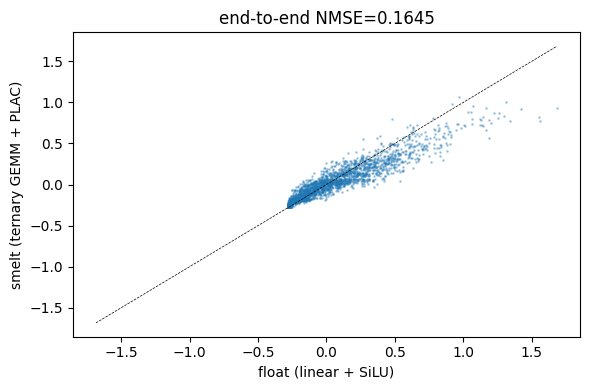

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    y_ref.detach().flatten().numpy(),
    y_smelt.detach().flatten().numpy(),
    s=1,
    alpha=0.3,
)
lim = max(y_ref.abs().max().item(), y_smelt.abs().max().item())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("float (linear + SiLU)")
ax.set_ylabel("smelt (ternary GEMM + PLAC)")
ax.set_title(f"end-to-end NMSE={nmse:.4f}")
plt.tight_layout()
plt.show()

## Bench

CPU: Intel(R) Core(TM) i7-9750H CPU @ 2.60GHz
GPU: NVIDIA GeForce GTX 1650


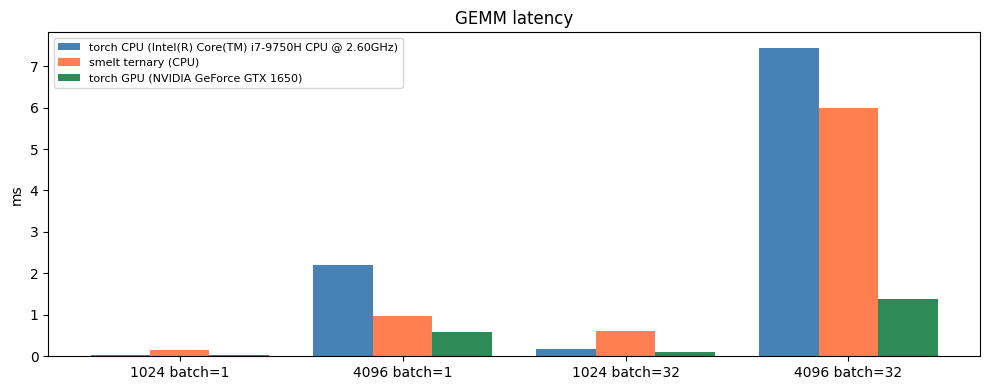

      1024 batch=1: cpu=0.03ms  smelt=0.15ms  5.3x slower  gpu=0.04ms
      4096 batch=1: cpu=2.20ms  smelt=0.97ms  2.3x faster  gpu=0.58ms
     1024 batch=32: cpu=0.17ms  smelt=0.60ms  3.5x slower  gpu=0.09ms
     4096 batch=32: cpu=7.44ms  smelt=6.00ms  1.2x faster  gpu=1.39ms


In [8]:
import platform
import subprocess
import time


def get_cpu_name():
    try:
        out = subprocess.check_output(["lscpu"], text=True)
        for line in out.splitlines():
            if "Model name" in line:
                return line.split(":")[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()


cpu_name = get_cpu_name()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f"CPU: {cpu_name}")
if gpu_name:
    print(f"GPU: {gpu_name}")

results = []
for batch, label in [(1, "batch=1"), (32, "batch=32")]:
    for k in [1024, 4096]:
        linear_layer = nn.Linear(k, k, bias=False)
        tl = TernaryLinear(linear_layer)
        xb = torch.randn(batch, k)

        linear_layer(xb)
        t0 = time.perf_counter()
        for _ in range(100):
            linear_layer(xb)
        t_cpu = (time.perf_counter() - t0) / 100

        tl(xb)
        t0 = time.perf_counter()
        for _ in range(100):
            tl(xb)
        t_smelt = (time.perf_counter() - t0) / 100

        t_gpu = None
        if torch.cuda.is_available():
            lg = linear_layer.cuda()
            xg = xb.cuda()
            for _ in range(10):
                lg(xg)
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(100):
                lg(xg)
            torch.cuda.synchronize()
            t_gpu = (time.perf_counter() - t0) / 100

        results.append(
            {
                "name": f"{k} {label}",
                "cpu": t_cpu * 1e3,
                "smelt": t_smelt * 1e3,
                "gpu": t_gpu * 1e3 if t_gpu else None,
            }
        )

names = [r["name"] for r in results]
has_gpu = any(r["gpu"] is not None for r in results)
x_pos = np.arange(len(names))
w = 0.8 / (3 if has_gpu else 2)

fig, ax = plt.subplots(figsize=(10, 4))
cpu_label = f"torch CPU ({cpu_name})"
ax.bar(x_pos - w, [r["cpu"] for r in results], w, label=cpu_label, color="steelblue")
ax.bar(x_pos, [r["smelt"] for r in results], w, label="smelt ternary (CPU)", color="coral")
if has_gpu:
    ax.bar(
        x_pos + w,
        [r["gpu"] or 0 for r in results],
        w,
        label=f"torch GPU ({gpu_name})",
        color="seagreen",
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.set_ylabel("ms")
ax.legend(fontsize=8)
ax.set_title("GEMM latency")
plt.tight_layout()
plt.show()

for r in results:
    ratio = r["cpu"] / r["smelt"]
    tag = f"{ratio:.1f}x faster" if ratio > 1 else f"{1 / ratio:.1f}x slower"
    line = f"  {r['name']:>16s}: cpu={r['cpu']:.2f}ms  smelt={r['smelt']:.2f}ms  {tag}"
    if r["gpu"] is not None:
        line += f"  gpu={r['gpu']:.2f}ms"
    print(line)